                             **Atelier Matplotlib**


In [26]:
import pandas as pd
import matplotlib.pyplot as plt

In [27]:
df = pd.read_csv("../data/mesures_capteurs.csv")

In [28]:
df.head()

,id_mesure,date_heure,id_capteur,batiment,temperature,humidite,pression,consommation,etat
0,M0413,2026-01-22 04:00:00,C005,B002,25.46,58.06,1008.95,287.28,OK
1,M0290,2026-01-17 01:00:00,C002,B001,24.00,79.73,993.39,116.20,OK
2,M0077,2026-01-08 04:00:00,C005,B002,25.82,54.47,1010.32,288.50,OK
3,M0079,2026-01-08 06:00:00,C007,B003,28.23,69.39,1019.62,136.65,OK
4,M0183,2026-01-12 14:00:00,C003,B001,20.58,53.80,1016.58,182.62,OK


In [ ]:
pd

**CONVERSION DE LA COLONNE DATE**
Actuellement "date_heure" est du texte (string) : "2026-01-22 04:00:00"
 pd.to_datetime() la convertit en vraie date/heure => indispensable pour bien tracer un graphique temporel

 ===== VERIFICATION =====
df.head()   # affiche les 5 premières lignes pour vérifier que tout est bien chargé

In [29]:
df["date_heure"] = pd.to_datetime(df["date_heure"])
df.head()

,id_mesure,date_heure,id_capteur,batiment,temperature,humidite,pression,consommation,etat
0,M0413,2026-01-22 04:00:00,C005,B002,25.46,58.06,1008.95,287.28,OK
1,M0290,2026-01-17 01:00:00,C002,B001,24.00,79.73,993.39,116.20,OK
2,M0077,2026-01-08 04:00:00,C005,B002,25.82,54.47,1010.32,288.50,OK
3,M0079,2026-01-08 06:00:00,C007,B003,28.23,69.39,1019.62,136.65,OK
4,M0183,2026-01-12 14:00:00,C003,B001,20.58,53.80,1016.58,182.62,OK


# Partie 1 – Graphique linéaire (Line Plot)

Syntaxe
* plt.plot(x, y, label="...")   # trace la courbe
* plt.title("...")              # titre du graphique
* plt.xlabel("...")             # nom de l'axe X
* plt.ylabel("...")             # nom de l'axe Y
* plt.legend()                  # affiche la légende (utilise le "label")
* plt.grid(True)                # affiche la grille
* plt.show()                    # affiche le graphique

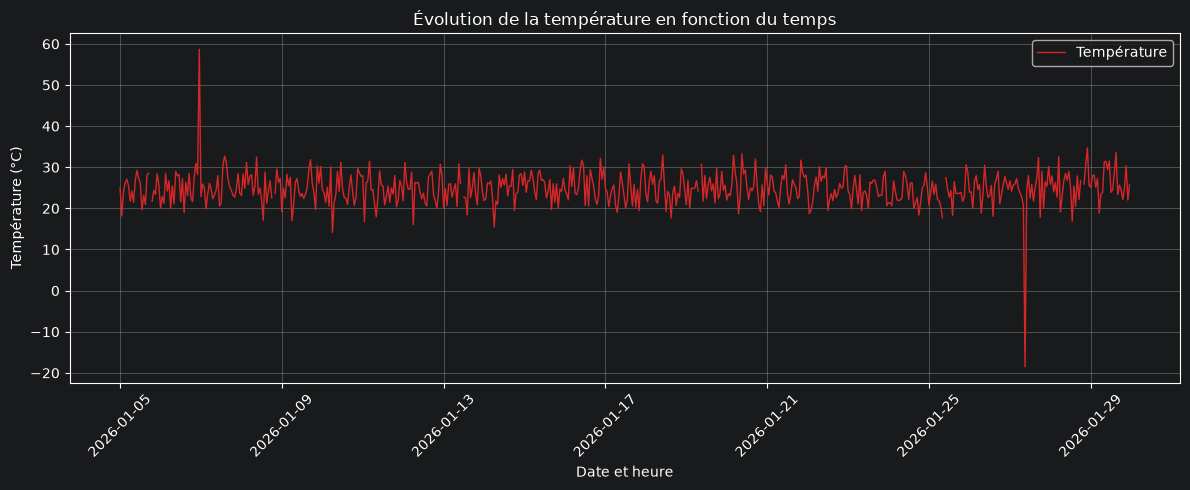

In [30]:

# ===== TRI DES DONNEES PAR DATE (important pour un line plot propre) =====
# Sans ça, la courbe peut "zigzaguer" si les lignes ne sont pas dans l'ordre chronologique
df_sorted = df.sort_values("date_heure")

# ===== CREATION DE LA FIGURE =====
plt.figure(figsize=(12, 5))   # figsize = (largeur, hauteur) en pouces, pour un graphique plus lisible

# ===== TRACE DE LA COURBE =====
plt.plot(
    df_sorted["date_heure"],     # axe X : le temps
    df_sorted["temperature"],    # axe Y : la température
    label="Température",         # texte affiché dans la légende
    color="tab:red",             # couleur de la courbe
    linewidth=1                  # épaisseur de la ligne
)

# ===== HABILLAGE DU GRAPHIQUE =====
plt.title("Évolution de la température en fonction du temps")  # titre principal
plt.xlabel("Date et heure")            # nom axe X
plt.ylabel("Température (°C)")         # nom axe Y
plt.legend()                           # affiche la légende (relie "tab:red" à "Température")
plt.grid(True)                         # ajoute une grille pour faciliter la lecture des valeurs

# ===== AJUSTEMENTS D'AFFICHAGE =====
plt.xticks(rotation=45)     # incline les dates sur l'axe X pour qu'elles ne se chevauchent pas
plt.tight_layout()          # ajuste automatiquement les marges pour que rien ne soit coupé

# ===== AFFICHAGE FINAL =====
plt.show()

**2) Identifier les valeurs anormales**

Regarde le graphique généré et repère :

des photos soudaines (température qui saute brutalement au-dessus/en dessous du reste)
des valeurs physiquement impossibles (ex : température négative extrême, ou très proche de 0 si ce n'est pas cohérent avec le contexte)
des trous dans la courbe (dus aux valeurs manquantes qu'on a vues : 6 NaN dans temperature)

In [31]:
# ===== BONUS : lister automatiquement les valeurs extrêmes pour t'aider à répondre =====
# On regarde les températures les plus hautes et les plus basses du dataset
print("Températures les plus élevées :")
print(df_sorted.nlargest(5, "temperature")[["date_heure", "batiment", "temperature"]])

print("\nTempératures les plus basses :")
print(df_sorted.nsmallest(5, "temperature")[["date_heure", "batiment", "temperature"]])

Températures les plus élevées :
             date_heure batiment  temperature
502 2026-01-06 23:00:00     B004        58.70
43  2026-01-28 22:00:00     B004        34.72
129 2026-01-29 15:00:00     B002        33.60
211 2026-01-20 09:00:00     B004        33.29
165 2026-01-18 10:00:00     B004        33.01

Températures les plus basses :
             date_heure batiment  temperature
487 2026-01-27 09:00:00     B004       -18.50
245 2026-01-10 06:00:00     B003        14.11
258 2026-01-14 06:00:00     B003        15.49
249 2026-01-12 06:00:00     B003        16.04
59  2026-01-11 01:00:00     B001        16.77


# Partie 2 – Diagramme en barres (Bar Chart)

Partie 2 – Diagramme en barres (Bar Chart)

Objectif : comparer la consommation énergétique moyenne entre les 4 bâtiments (B001, B002, B003, B004). Contrairement au line plot (évolution continue), le bar chart compare des catégories discrètes.

Syntaxe de base :

python
plt.bar(x, height)     # barres verticales
plt.barh(y, width)     # barres horizontales

**1) Calcul de consommation_batiment (consommation moyenne par bâtiment)**

In [32]:
# ===== CALCUL DE LA MOYENNE PAR BATIMENT =====
# groupby("batiment") regroupe toutes les lignes ayant le même bâtiment
# ["consommation"].mean() calcule la moyenne de consommation pour chaque groupe
consommation_batiment = df.groupby("batiment")["consommation"].mean()

# ===== VERIFICATION =====
print(consommation_batiment)

batiment
B001    177.870927
B002    221.785333
B003    153.191000
B004    282.552282
Name: consommation, dtype: float64


**2) Bar chart vertical — comparaison des bâtiments**

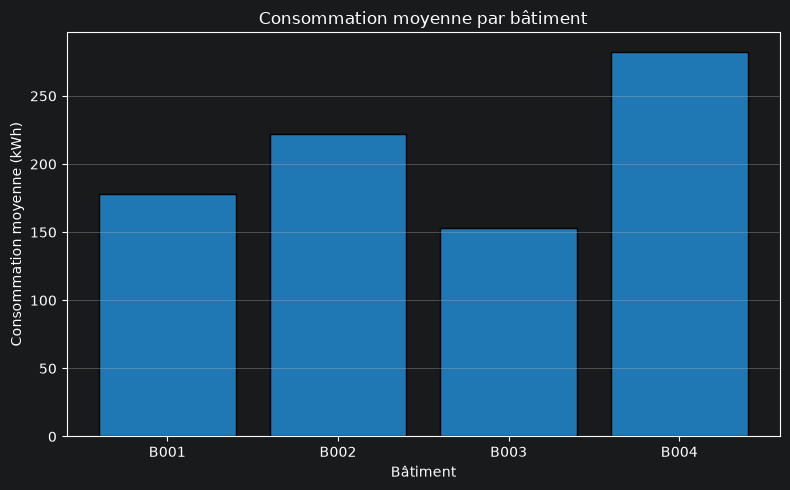

In [33]:
# ===== CREATION DE LA FIGURE =====
plt.figure(figsize=(8, 5))

# ===== TRACE DES BARRES VERTICALES =====
plt.bar(
    consommation_batiment.index,     # axe X : noms des bâtiments (B001, B002, B003, B004)
    consommation_batiment.values,    # axe Y : valeurs moyennes de consommation
    color="tab:blue",
    edgecolor="black"                # contour noir pour mieux distinguer chaque barre
)

# ===== HABILLAGE =====
plt.title("Consommation moyenne par bâtiment")
plt.xlabel("Bâtiment")
plt.ylabel("Consommation moyenne (kWh)")
plt.grid(axis="y")   # grille horizontale seulement, utile pour lire les hauteurs de barres

plt.tight_layout()
plt.show()

# Partie 3 – Histogramme

visualiser la distribution (répartition des fréquences) d'une variable continue en la divisant en intervalles (classes/bins). Différent du bar chart : ici on regroupe des valeurs numériques continues, pas des catégories.

Syntaxe de base :

plt.hist(data, bins=20)   # bins = nombre de classes/intervalles

**1) Histogramme de la température (20 classes, grille horizontale uniquement)**

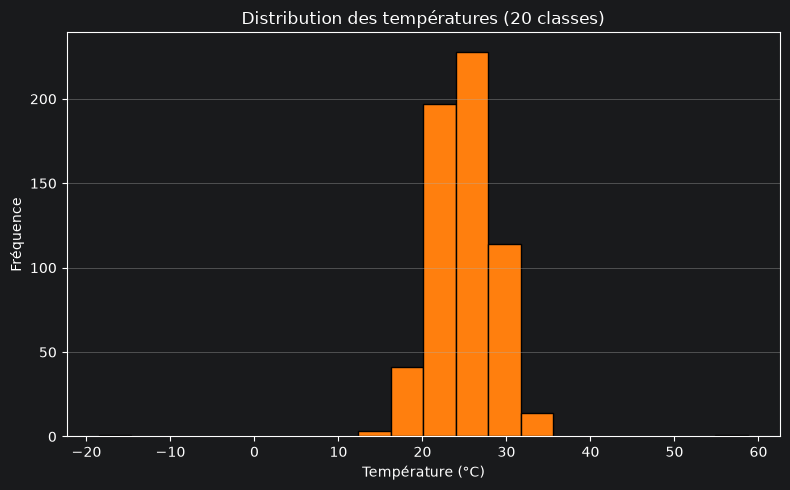

In [34]:
# ===== PREPARATION DES DONNEES =====
# On rappelle qu'il y a 6 valeurs manquantes dans "temperature" (vu à la vérification)
# .dropna() les retire pour ne pas fausser l'histogramme
temperature_clean = df["temperature"].dropna()

# ===== CREATION DE LA FIGURE =====
plt.figure(figsize=(8, 5))

# ===== TRACE DE L'HISTOGRAMME =====
plt.hist(
    temperature_clean,
    bins=20,              # on divise la plage des températures en 20 classes
    color="tab:orange",
    edgecolor="black"     # contour noir pour bien distinguer chaque barre
)

# ===== HABILLAGE =====
plt.title("Distribution des températures (20 classes)")
plt.xlabel("Température (°C)")
plt.ylabel("Fréquence")

# ===== GRILLE HORIZONTALE UNIQUEMENT =====
# axis="y" => n'affiche que les lignes horizontales de la grille (demandé dans l'énoncé)
plt.grid(axis="y")

plt.tight_layout()
plt.show()

In [35]:
# ===== STATISTIQUES POUR AIDER TON ANALYSE =====
print(temperature_clean.describe())

count    599.000000
mean      24.878314
std        4.059576
min      -18.500000
25%       22.570000
50%       24.860000
75%       27.275000
max       58.700000
Name: temperature, dtype: float64


3) Histogramme de la consommation (20 classes)

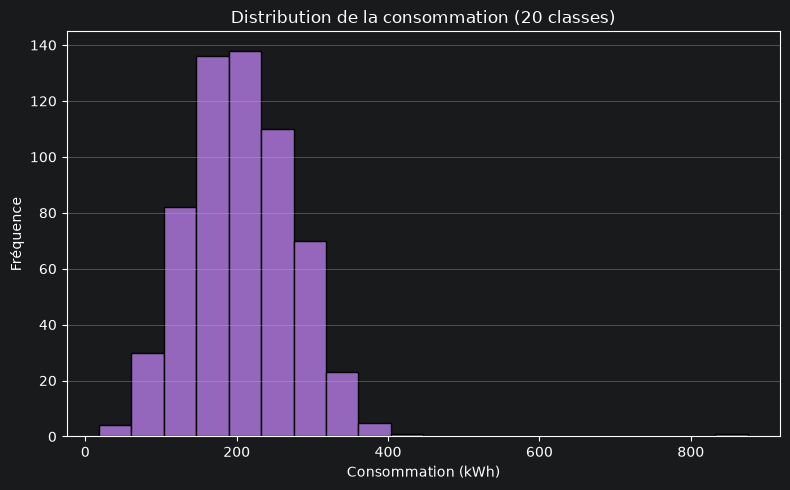

In [36]:
# ===== PREPARATION DES DONNEES =====
# 5 valeurs manquantes dans "consommation" => on les retire aussi
consommation_clean = df["consommation"].dropna()

plt.figure(figsize=(8, 5))
plt.hist(consommation_clean, bins=20, color="tab:purple", edgecolor="black")
plt.title("Distribution de la consommation (20 classes)")
plt.xlabel("Consommation (kWh)")
plt.ylabel("Fréquence")
plt.grid(axis="y")
plt.tight_layout()
plt.show()

3a) Avec 10 classes

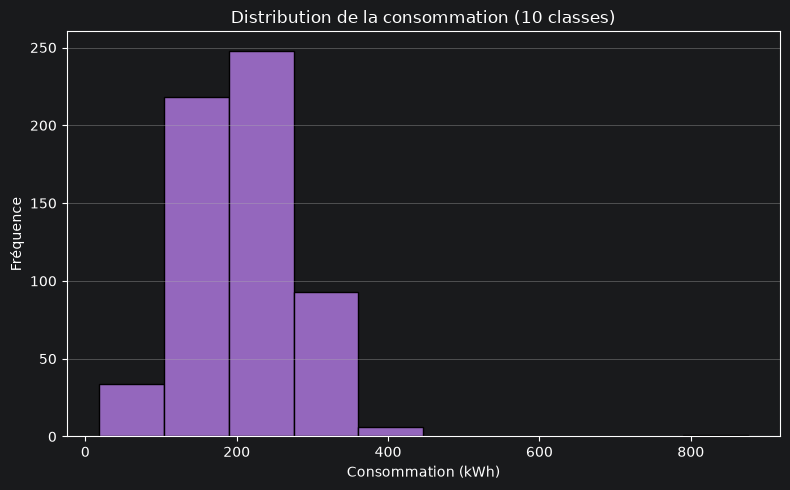

In [37]:
plt.figure(figsize=(8, 5))
plt.hist(consommation_clean, bins=10, color="tab:purple", edgecolor="black")  # bins=10
plt.title("Distribution de la consommation (10 classes)")
plt.xlabel("Consommation (kWh)")
plt.ylabel("Fréquence")
plt.grid(axis="y")
plt.tight_layout()
plt.show()

3b) Avec 30 classes

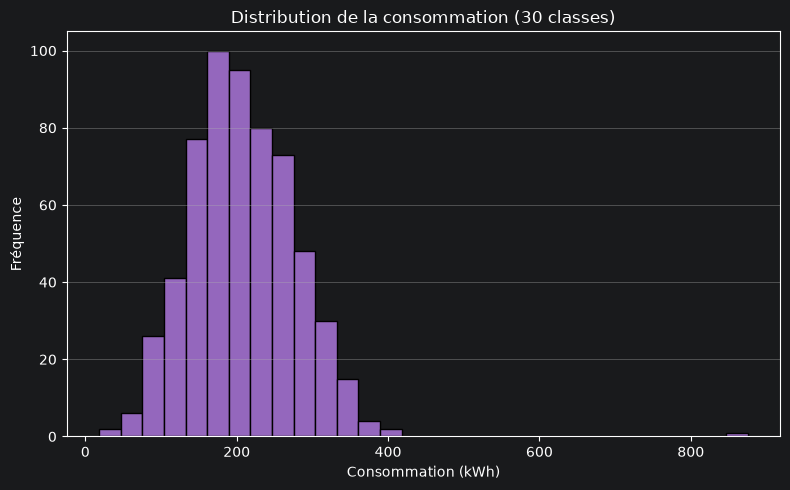

In [38]:
plt.figure(figsize=(8, 5))
plt.hist(consommation_clean, bins=30, color="tab:purple", edgecolor="black")  # bins=30
plt.title("Distribution de la consommation (30 classes)")
plt.xlabel("Consommation (kWh)")
plt.ylabel("Fréquence")
plt.grid(axis="y")
plt.tight_layout()
plt.show()

# Partie 4 – Nuage de points (Scatter Plot)
visualiser s'il existe une relation/corrélation entre deux variables numériques continues (température et consommation). Chaque point représente une mesure du dataset.

Syntaxe de base :

plt.scatter(x, y)   # x et y = deux variables numériques

**1) Nuage de points température vs consommation**


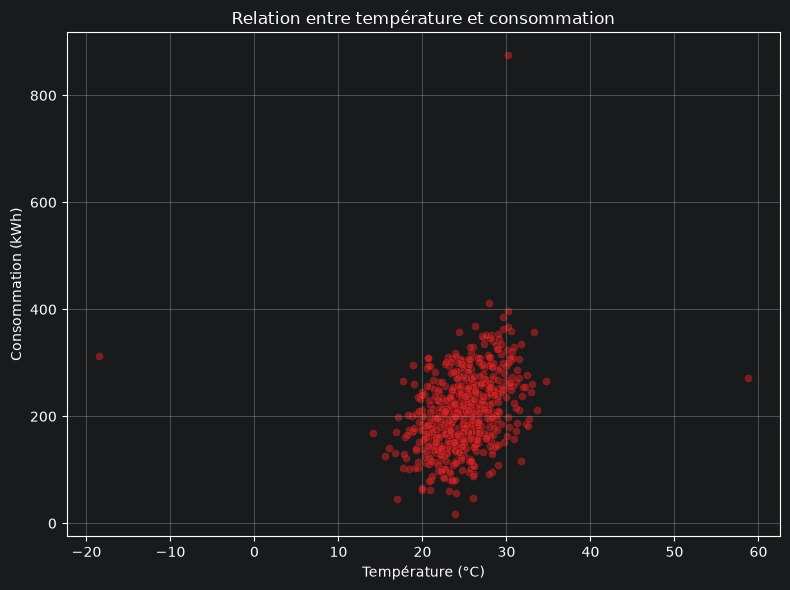

In [39]:
# ===== PREPARATION DES DONNEES =====
# Pour comparer les deux colonnes ensemble, on retire les lignes où l'une des deux est manquante
# (sinon matplotlib peut planter ou afficher des points incohérents)
df_scatter = df.dropna(subset=["temperature", "consommation"])

# ===== CREATION DE LA FIGURE =====
plt.figure(figsize=(8, 6))

# ===== TRACE DU NUAGE DE POINTS =====
plt.scatter(
    df_scatter["temperature"],      # axe X : température
    df_scatter["consommation"],     # axe Y : consommation
    alpha=0.5,                      # transparence (0=invisible, 1=opaque) => aide à voir les zones où les points se superposent
    color="tab:red",
    edgecolor="black",
    linewidth=0.3
)

# ===== HABILLAGE =====
plt.title("Relation entre température et consommation")
plt.xlabel("Température (°C)")
plt.ylabel("Consommation (kWh)")
plt.grid(True)

plt.tight_layout()
plt.show()

Il existe une relation positive mais faible/modérée entre la température et la consommation : quand la température augmente, la consommation a tendance à augmenter légèrement aussi (probablement lié à la climatisation dans les bâtiments). Mais la corrélation est loin d'être forte (elle serait proche de 0.7–1 pour une relation forte), donc beaucoup d'autres facteurs influencent la consommation (bâtiment, heure de la journée, humidité, etc.) en plus de la température.

À noter aussi (utile pour repérer les valeurs anormales des parties précédentes) :

Température min : -18.5°C et max : 58.7°C → ces deux valeurs sont probablement des anomalies/valeurs aberrantes (peu réaliste pour un bâtiment de bureau, sauf capteur défaillant)
Consommation max : 875 kWh contre une moyenne de ~208 kWh → potentiellement un pic anormal aussi

# Partie 5 – Box plot (diagramme à moustaches)

résumer une distribution en un coup d'œil grâce à 5 indicateurs clés : minimum, 1er quartile (Q1), médiane, 3e quartile (Q3), maximum — et repérer les valeurs extrêmes (outliers).

Syntaxe de base :

plt.boxplot(data)

**Anatomie d'un box plot :**

La boîte = zone entre Q1 (25%) et Q3 (75%) des données → contient 50% des valeurs centrales
La ligne au milieu de la boîte = médiane
Les moustaches = s'étendent jusqu'aux valeurs "normales" les plus extrêmes
Les points isolés au-delà des moustaches = valeurs aberrantes (outliers)

1) Box plot de la température (sans valeurs manquantes, grille horizontale uniquement)

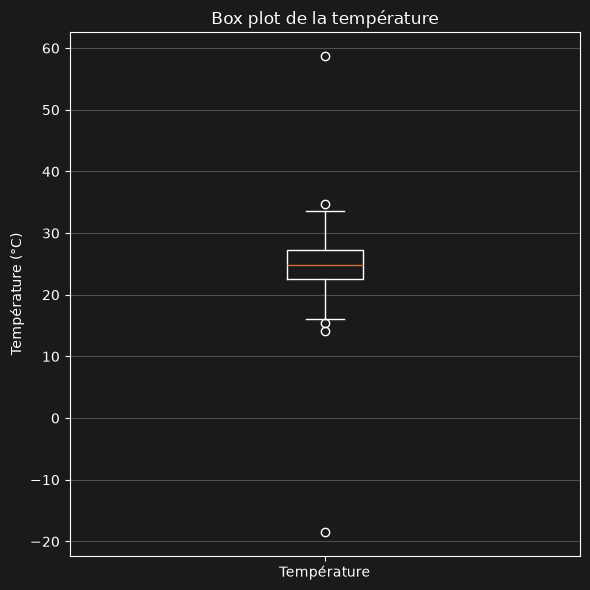

In [40]:
# ===== PREPARATION DES DONNEES =====
# On supprime les valeurs manquantes AVANT de construire le graphique (demandé dans l'énoncé)
temperature_clean = df["temperature"].dropna()

# ===== CREATION DE LA FIGURE =====
plt.figure(figsize=(6, 6))

# ===== TRACE DU BOX PLOT =====
plt.boxplot(
    temperature_clean,
    tick_labels=["Température"]   # nom affiché sous la boîte
)

# ===== HABILLAGE =====
plt.title("Box plot de la température")
plt.ylabel("Température (°C)")

# ===== GRILLE HORIZONTALE UNIQUEMENT =====
plt.grid(axis="y")

plt.tight_layout()
plt.show()

**2) Que représentent les points en dehors des moustaches ?**

Ce sont les valeurs aberrantes (outliers) : des mesures de température anormalement hautes ou basses par rapport à la majorité des données. Elles se situent au-delà de 1.5 × l'écart interquartile (IQR) depuis Q1 ou Q3. Dans notre cas, on avait déjà repéré à la Partie 4 des valeurs extrêmes comme -18.5°C et 58.7°C — elles apparaîtront probablement ici comme des points isolés.

3) Box plot de la consommation

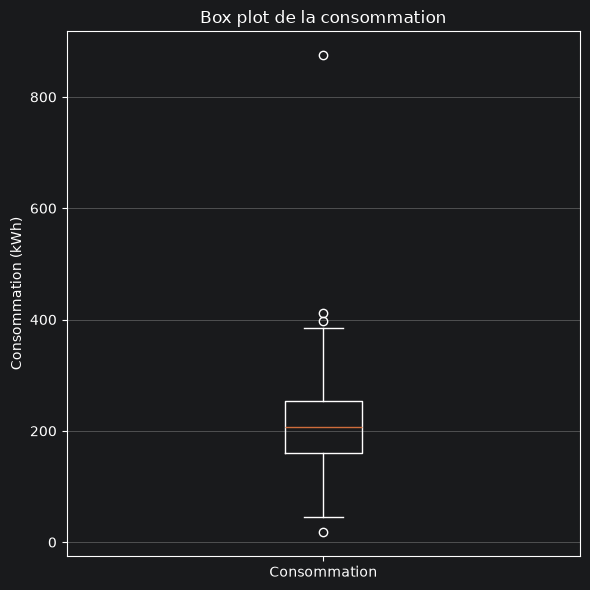

In [41]:
# ===== PREPARATION DES DONNEES =====
consommation_clean = df["consommation"].dropna()

plt.figure(figsize=(6, 6))
plt.boxplot(consommation_clean, tick_labels=["Consommation"])
plt.title("Box plot de la consommation")
plt.ylabel("Consommation (kWh)")
plt.grid(axis="y")
plt.tight_layout()
plt.show()

La médiane de la température (~25°C) est cohérente avec un environnement de bureau climatisé.
La boîte de la consommation est beaucoup plus large (IQR = 93.95) que celle de la température (IQR = 4.70) — mais ce n'est pas directement comparable car les échelles sont différentes (°C vs kWh).
Les moustaches de la consommation couvrent une plage bien plus large (19 à 395) que celles de la température (15 à 34).
Les deux variables ont des outliers : la température a des valeurs extrêmes basses (-18.5°C) et hautes (58.7°C) peu réalistes → probablement des erreurs de capteur. La consommation a un pic extrême à 875 kWh, largement au-dessus du reste.

Oui, la consommation présente davantage de dispersion (relative) que la température. Le coefficient de variation (écart-type / moyenne, en %) est de 34.6% pour la consommation contre seulement 16.3% pour la température. Cela confirme visuellement ce qu'on observe sur les box plots : la boîte et les moustaches de la consommation sont proportionnellement plus étendues.

# Partie 6 – Diagramme circulaire (Pie Chart)

montrer la répartition en pourcentage d'une variable catégorielle — ici, l'état des capteurs (OK, ALERTE, ERREUR).

**Syntaxe de base :**

plt.pie(values, labels=..., autopct=...)

1) Diagramme circulaire de la répartition des états
python
# ===== COMPTAGE DES ETATS =====
# value_counts() compte combien de fois chaque état apparaît dans la colonne "etat"
# Rappel : on avait vu 4 valeurs manquantes (NaN) dans cette colonne à la vérification
etats = df["etat"].value_counts()

# ===== VERIFICATION =====
print(etats)

# ===== CREATION DE LA FIGURE =====
plt.figure(figsize=(7, 7))

# ===== TRACE DU DIAGRAMME CIRCULAIRE =====
plt.pie(
    etats.values,                     # les valeurs (nombre de capteurs par état)
    labels=etats.index,               # les noms affichés (OK, ALERTE, ERREUR)
    autopct="%1.1f%%",                # affiche le pourcentage avec 1 décimale sur chaque part
    colors=["tab:green", "tab:orange", "tab:red"],  # vert=OK, orange=ALERTE, rouge=ERREUR
    startangle=90                     # démarre le premier segment à midi (visuellement plus lisible)
)

# ===== HABILLAGE =====
plt.title("Répartition des états des capteurs")

plt.show()

⚠️ Remarque importante : value_counts() ignore automatiquement les NaN par défaut. Donc les 4 lignes avec état manquant ne sont pas comptées dans le pie chart. Si tu veux les inclure comme catégorie "Inconnu" :

python
===== VERSION ALTERNATIVE : inclure les valeurs manquantes comme catégorie =====
etats_avec_nan = df["etat"].value_counts(dropna=False)
etats_avec_nan.index = etats_avec_nan.index.fillna("Inconnu")
print(etats_avec_nan)
**2) Interprétation des proportions**


etat
OK        567
ALERTE     29
ERREUR      5
Name: count, dtype: int64


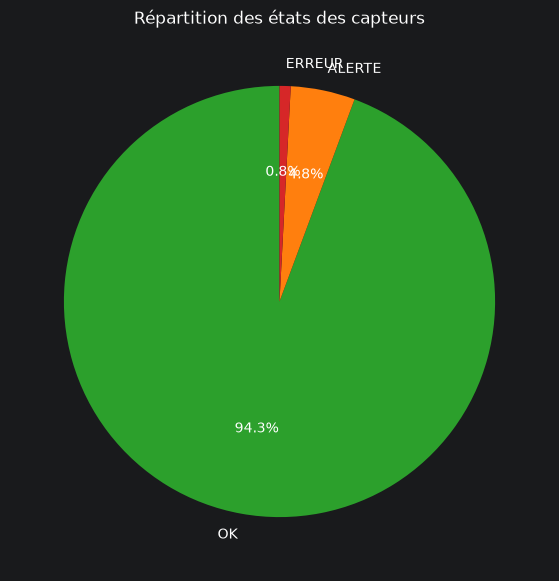

In [42]:
# ===== COMPTAGE DES ETATS =====
# value_counts() compte combien de fois chaque état apparaît dans la colonne "etat"
# Rappel : on avait vu 4 valeurs manquantes (NaN) dans cette colonne à la vérification
etats = df["etat"].value_counts()

# ===== VERIFICATION =====
print(etats)

# ===== CREATION DE LA FIGURE =====
plt.figure(figsize=(7, 7))

# ===== TRACE DU DIAGRAMME CIRCULAIRE =====
plt.pie(
    etats.values,                     # les valeurs (nombre de capteurs par état)
    labels=etats.index,               # les noms affichés (OK, ALERTE, ERREUR)
    autopct="%1.1f%%",                # affiche le pourcentage avec 1 décimale sur chaque part
    colors=["tab:green", "tab:orange", "tab:red"],  # vert=OK, orange=ALERTE, rouge=ERREUR
    startangle=90                     # démarre le premier segment à midi (visuellement plus lisible)
)

# ===== HABILLAGE =====
plt.title("Répartition des états des capteurs")

plt.show()

**2) interpréter la proportion de capteurs OK ; proportion ALERTE ;  proportion ERREUR**

Sur les 601 mesures avec un état renseigné (4 valeurs manquantes exclues) :

OK : 94.3% (567 capteurs) → la grande majorité du parc de capteurs fonctionne normalement, ce qui est rassurant.
ALERTE : 4.8% (29 capteurs) → une petite portion nécessite une surveillance, sans être critique.
ERREUR : 0.8% (5 capteurs) → très peu de capteurs sont en panne complète, ce qui est un bon signe pour la fiabilité du système IoT.

Globalement, le parc de capteurs est en bon état de santé (plus de 94% opérationnels), avec un risque limité (moins de 1% en erreur totale).

# Partie 7 : Plusieurs courbes sur un même graphique


comparer l'évolution de la température entre les 4 bâtiments sur un seul graphique, pour voir si certains bâtiments ont des comportements différents.

Syntaxe de base : appeler plt.plot() plusieurs fois avant plt.show() → chaque appel ajoute une courbe sur la même figure.

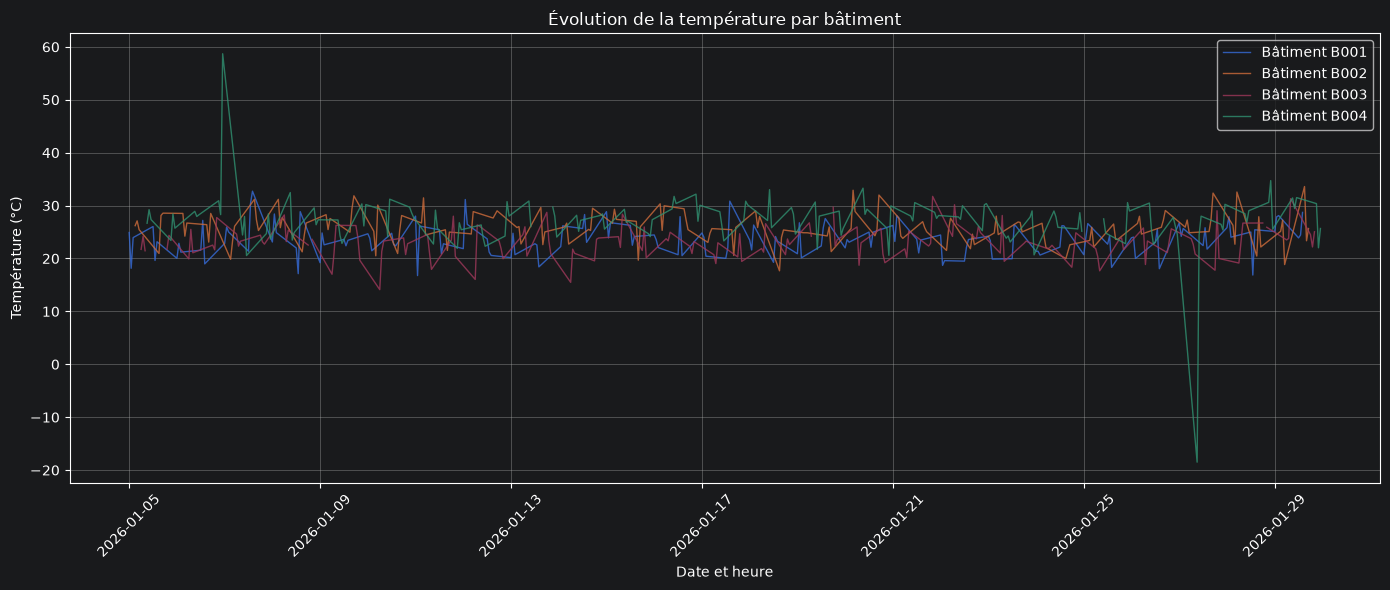

In [43]:
# ===== TRI DES DONNEES PAR DATE =====
# Important pour que chaque courbe soit tracée dans l'ordre chronologique
df_sorted = df.sort_values("date_heure")

# ===== CREATION DE LA FIGURE =====
plt.figure(figsize=(14, 6))

# ===== BOUCLE SUR CHAQUE BATIMENT =====
# df["batiment"].unique() renvoie la liste des bâtiments uniques : B001, B002, B003, B004
for batiment in sorted(df_sorted["batiment"].unique()):

    # on filtre les données pour ne garder que ce bâtiment
    subset = df_sorted[df_sorted["batiment"] == batiment]

    # on trace la courbe de ce bâtiment
    # label=f"Bâtiment {batiment}" => chaque courbe aura son propre nom dans la légende
    plt.plot(
        subset["date_heure"],
        subset["temperature"],
        label=f"Bâtiment {batiment}",
        linewidth=1,
        alpha=0.8   # légère transparence pour mieux voir les courbes qui se superposent
    )

# ===== HABILLAGE =====
plt.title("Évolution de la température par bâtiment")
plt.xlabel("Date et heure")
plt.ylabel("Température (°C)")
plt.legend()          # affiche la légende avec les 4 bâtiments
plt.grid(True)

# ===== AJUSTEMENTS D'AFFICHAGE =====
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

**Observation :**

B004 se démarque nettement : température moyenne la plus élevée (27.12°C) et surtout un écart-type beaucoup plus grand (5.37 contre ~3 pour les autres). C'est aussi ce bâtiment qui contient les valeurs extrêmes déjà repérées (-18.5°C et 58.7°C) → probablement un capteur défaillant dans ce bâtiment.
B001, B002, B003 ont des comportements similaires (moyennes entre 23°C et 26°C, écarts-types proches de 3), ce qui suggère un fonctionnement normal et homogène.
Sur le graphique, la courbe de B004 devrait montrer les pics/creux les plus visibles.


# Partie 8 – Sauvegarde des graphiques

exporter le graphique de la Partie 1 (évolution température/temps) en fichier PNG et PDF, dans le dossier exports/.

Syntaxe clé : plt.savefig("chemin", ...) doit être appelé avant plt.show(). Une fois plt.show() exécuté, la figure est "vidée" de la mémoire, et sauvegarder après donnerait un fichier vide ou une erreur.

In [44]:
# plt.savefig("chemin/fichier.png", dpi=300)   # image, dpi = résolution
# plt.savefig("chemin/fichier.pdf")         # format vectoriel, toujours net

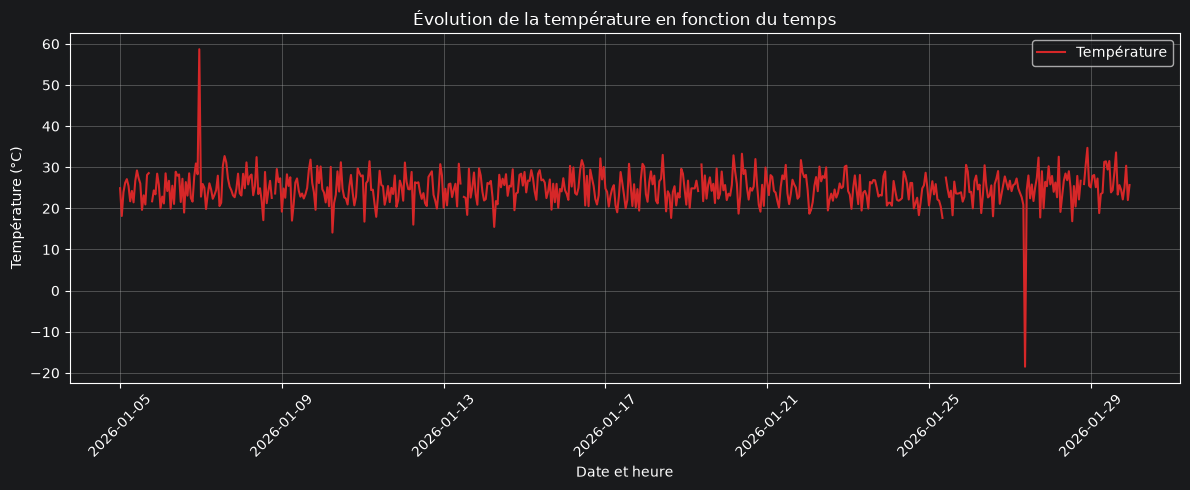

In [45]:
# ===== RECREATION DU GRAPHIQUE (température en fonction du temps) =====
df_sorted = df.sort_values("date_heure")

plt.figure(figsize=(12, 5))
plt.plot(df_sorted["date_heure"], df_sorted["temperature"], label="Température", color="tab:red")
plt.title("Évolution de la température en fonction du temps")
plt.xlabel("Date et heure")
plt.ylabel("Température (°C)")
plt.legend()
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()

# ===== 1) SAUVEGARDE EN PNG =====
# IMPORTANT : savefig() doit être appelé AVANT plt.show(), sinon le fichier sera vide
plt.savefig("../exports/temperature.png", dpi=300)

# ===== 2) SAUVEGARDE EN PDF =====
plt.savefig("../exports/temperature.pdf")

# ===== AFFICHAGE (en dernier) =====
plt.show()